# Geographic Data Gap Analysis + O*NET Classification Dataset

**Goals:**
1. Identify which countries have AI usage data in the AEI releases
2. Measure the gap between global observed exposure and country-level adoption
3. Build a classification dataset using O*NET categories only (no external country data)
4. Prepare for recommendation system: Industry + Country → Retraining urgency

In [1]:
from huggingface_hub import hf_hub_download
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO      = 'Anthropic/EconomicIndex'
REPO_TYPE = 'dataset'

def load(path, sep=','):
    local = hf_hub_download(repo_id=REPO, filename=path, repo_type=REPO_TYPE)
    df = pd.read_csv(local, sep=sep)
    print(f'FILE : {path}')
    print(f'shape: {df.shape}')
    print(f'cols : {df.columns.tolist()}')
    print()
    return df

print('Ready.')

Ready.


---
## Step 1 — Reload confirmed tables from previous notebook

In [2]:
job_exposure     = load('labor_market_impacts/job_exposure.csv')
task_penetration = load('labor_market_impacts/task_penetration.csv')
wages            = load('release_2025_02_10/wage_data.csv')
soc              = load('release_2025_02_10/SOC_Structure.csv')
onet_tasks       = load('release_2025_02_10/onet_task_statements.csv')

FILE : labor_market_impacts/job_exposure.csv
shape: (756, 3)
cols : ['occ_code', 'title', 'observed_exposure']

FILE : labor_market_impacts/task_penetration.csv
shape: (17998, 2)
cols : ['task', 'penetration']

FILE : release_2025_02_10/wage_data.csv
shape: (1090, 10)
cols : ['SOCcode', 'JobName', 'JobFamily', 'isBright', 'isGreen', 'JobZone', 'MedianSalary', 'JobForecast', 'ChanceAuto', 'WageGroup']

FILE : release_2025_02_10/SOC_Structure.csv
shape: (1596, 6)
cols : ['Major Group', 'Minor Group', 'Broad Occupation', 'Detailed Occupation', 'Detailed O*NET-SOC', 'SOC or O*NET-SOC 2019 Title']

FILE : release_2025_02_10/onet_task_statements.csv
shape: (19530, 8)
cols : ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']



In [3]:
# Rebuild master from previous notebook
wages['occ_code'] = wages['SOCcode'].str[:7]
wages_deduped = (
    wages
    .sort_values('JobForecast', ascending=False)
    .drop_duplicates(subset='occ_code', keep='first')
)

master = job_exposure.merge(
    wages_deduped[['occ_code', 'JobFamily', 'JobZone', 'MedianSalary',
                   'JobForecast', 'ChanceAuto', 'isBright', 'WageGroup']],
    on='occ_code', how='left'
)

master['major_group_code'] = master['occ_code'].str[:2] + '-0000'
major_groups = (
    soc[soc['Major Group'].notna()]
    [['Major Group', 'SOC or O*NET-SOC 2019 Title']]
    .rename(columns={
        'Major Group': 'major_group_code',
        'SOC or O*NET-SOC 2019 Title': 'major_group_title'
    })
)
master = master.merge(major_groups, on='major_group_code', how='left')

print('Master shape:', master.shape)
print('Columns:', master.columns.tolist())

Master shape: (756, 12)
Columns: ['occ_code', 'title', 'observed_exposure', 'JobFamily', 'JobZone', 'MedianSalary', 'JobForecast', 'ChanceAuto', 'isBright', 'WageGroup', 'major_group_code', 'major_group_title']


---
## Step 2 — Inspect geographic data (Sep 2025 + Jan & Mar 2026 releases)

In [4]:
# Sep 2025 — enriched Claude.ai data (has geographic signals)
aei_sep25 = load('release_2025_09_15/data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv')
display(aei_sep25.head(3))

FILE : release_2025_09_15/data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv
shape: (136845, 11)
cols : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value', 'geo_name']



,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value,geo_name
0,ABW,country,2025-08-04,2025-08-11,Claude AI (Free and Pro),country,0,gdp_per_working_age_capita,NaN,55553.993646,Aruba
1,ABW,country,2025-08-04,2025-08-11,Claude AI (Free and Pro),country,0,usage_count,NaN,0.000000,Aruba
2,ABW,country,2025-08-04,2025-08-11,Claude AI (Free and Pro),country,0,usage_pct,NaN,0.000000,Aruba


In [5]:
# Jan 2026 — raw AEI data (claude.ai + 1P API)
aei_jan26_ai  = load('release_2026_01_15/data/intermediate/aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv')
aei_jan26_api = load('release_2026_01_15/data/intermediate/aei_raw_1p_api_2025-11-13_to_2025-11-20.csv')
display(aei_jan26_ai.head(3))
display(aei_jan26_api.head(3))

FILE : release_2026_01_15/data/intermediate/aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv
shape: (458778, 10)
cols : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']

FILE : release_2026_01_15/data/intermediate/aei_raw_1p_api_2025-11-13_to_2025-11-20.csv
shape: (187772, 10)
cols : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']



,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,AD,country,2025-11-13,2025-11-20,Claude AI (Free and Pro),ai_autonomy,0,ai_autonomy_count,NaN,70.000000
1,AD,country,2025-11-13,2025-11-20,Claude AI (Free and Pro),ai_autonomy,0,ai_autonomy_mean,NaN,3.300000
2,AD,country,2025-11-13,2025-11-20,Claude AI (Free and Pro),ai_autonomy,0,ai_autonomy_mean_ci_lower,NaN,3.114286


,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,GLOBAL,global,2025-11-13,2025-11-20,1P API,ai_autonomy,0,ai_autonomy_count,NaN,971450.000000
1,GLOBAL,global,2025-11-13,2025-11-20,1P API,ai_autonomy,0,ai_autonomy_mean,NaN,2.843552
2,GLOBAL,global,2025-11-13,2025-11-20,1P API,ai_autonomy,0,ai_autonomy_mean_ci_lower,NaN,2.841252


In [6]:
# Mar 2026 — latest
aei_mar26_ai  = load('release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv')
aei_mar26_api = load('release_2026_03_24/data/aei_raw_1p_api_2026-02-05_to_2026-02-12.csv')
display(aei_mar26_ai.head(3))
display(aei_mar26_api.head(3))

FILE : release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv
shape: (425257, 10)
cols : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']

FILE : release_2026_03_24/data/aei_raw_1p_api_2026-02-05_to_2026-02-12.csv
shape: (195156, 10)
cols : ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']



,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,directive,15.00000
1,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,directive,20.27027
2,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,learning,20.00000


,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,GLOBAL,global,2026-02-05,2026-02-12,1P API,ai_autonomy,0,ai_autonomy_count,NaN,1000000.000000
1,GLOBAL,global,2026-02-05,2026-02-12,1P API,ai_autonomy,0,ai_autonomy_mean,NaN,2.694321
2,GLOBAL,global,2026-02-05,2026-02-12,1P API,ai_autonomy,0,ai_autonomy_median,NaN,3.000000


---
## Step 3 — Identify geographic columns and available countries

Run this cell to find which column contains country/region information.

In [7]:
# Check each AEI file for geographic columns
geo_keywords = ['country', 'region', 'geo', 'location', 'nation', 'iso', 'code']

for name, df in [('aei_sep25', aei_sep25), ('aei_jan26_ai', aei_jan26_ai),
                 ('aei_jan26_api', aei_jan26_api), ('aei_mar26_ai', aei_mar26_ai),
                 ('aei_mar26_api', aei_mar26_api)]:
    geo_cols = [c for c in df.columns if any(k in c.lower() for k in geo_keywords)]
    print(f'{name}: geographic cols → {geo_cols}')
    for col in geo_cols:
        n_unique = df[col].nunique()
        print(f'  {col}: {n_unique} unique values — sample: {df[col].dropna().unique()[:8].tolist()}')
    print()

aei_sep25: geographic cols → ['geo_id', 'geography', 'geo_name']
  geo_id: 253 unique values — sample: ['ABW', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM']
  geography: 3 unique values — sample: ['country', 'global', 'state_us']
  geo_name: 252 unique values — sample: ['Aruba', 'Angola', 'Albania', 'Andorra', 'United Arab Emirates', 'Argentina', 'Armenia', 'American Samoa']

aei_jan26_ai: geographic cols → ['geo_id', 'geography']
  geo_id: 1265 unique values — sample: ['AD', 'AE', 'AG', 'AL', 'AM', 'AO', 'AR', 'AT']
  geography: 3 unique values — sample: ['country', 'global', 'country-state']

aei_jan26_api: geographic cols → ['geo_id', 'geography']
  geo_id: 1 unique values — sample: ['GLOBAL']
  geography: 1 unique values — sample: ['global']

aei_mar26_ai: geographic cols → ['geo_id', 'geography']
  geo_id: 1434 unique values — sample: ['AD', 'AE', 'AG', 'AL', 'AM', 'AO', 'AR', 'AT']
  geography: 3 unique values — sample: ['country', 'country-state', 'global']

aei_mar26_api: ge

In [9]:
# Use mar26 claude.ai — most countries, most recent
GEO_DF  = aei_mar26_ai
GEO_COL = 'geo_id'

# Filter to country level only (exclude global and country-state rows)
GEO_DF = GEO_DF[GEO_DF['geography'] == 'country'].copy()

country_counts = (
    GEO_DF[GEO_COL]
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'country', GEO_COL: 'count'})
)
print(f'Countries with data: {len(country_counts)}')
display(country_counts.head(30))

Countries with data: 177


,count,count
0,US,4632
1,IN,2402
2,GB,2232
3,FR,2110
4,DE,2048
5,JP,1988
6,KR,1984
7,CA,1966
8,BR,1850
9,IT,1644


In [11]:
indo = GEO_DF[GEO_DF['geo_id'] == 'ID']
print('Indonesia rows:', len(indo))
print('All columns:', indo.columns.tolist())
display(indo.head(5))

Indonesia rows: 1152
All columns: ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value']


,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
21922,ID,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,directive,4676.000000
21923,ID,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,directive,36.842105
21924,ID,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,feedback loop,1241.000000
21925,ID,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,feedback loop,9.777813
21926,ID,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,learning,2305.000000


In [12]:
print('Unique facets:')
print(GEO_DF['facet'].unique())

print('\nUnique levels:')
print(GEO_DF['level'].unique())

# For each facet, show sample cluster_names
for facet in GEO_DF['facet'].unique():
    sample = GEO_DF[GEO_DF['facet'] == facet]['cluster_name'].dropna().unique()[:8]
    variables = GEO_DF[GEO_DF['facet'] == facet]['variable'].unique()
    print(f'\nfacet={facet}')
    print(f'  variables   : {variables.tolist()}')
    print(f'  cluster_name sample: {sample.tolist()}')

Unique facets:
['collaboration' 'country' 'human_only_ability' 'multitasking'
 'task_success' 'use_case' 'onet_task' 'request']

Unique levels:
[0 1 2]

facet=collaboration
  variables   : ['collaboration_count', 'collaboration_pct']
  cluster_name sample: ['directive', 'learning', 'not_classified', 'task iteration', 'feedback loop', 'none', 'validation']

facet=country
  variables   : ['usage_count', 'usage_pct']
  cluster_name sample: []

facet=human_only_ability
  variables   : ['human_only_ability_count', 'human_only_ability_pct']
  cluster_name sample: ['not_classified', 'yes', 'no']

facet=multitasking
  variables   : ['multitasking_count', 'multitasking_pct']
  cluster_name sample: ['no', 'not_classified', 'yes']

facet=task_success
  variables   : ['task_success_count', 'task_success_pct']
  cluster_name sample: ['no', 'yes', 'not_classified']

facet=use_case
  variables   : ['use_case_count', 'use_case_pct']
  cluster_name sample: ['not_classified', 'personal', 'work', 'course

---
## Step 4 — Find task-level column in AEI data

We need to know which column maps to O*NET tasks so we can compute
per-country task penetration and compare it to the global baseline.

In [13]:
# Filter to onet_task facet, pct variable only
onet_geo = GEO_DF[
    (GEO_DF['facet'] == 'onet_task') &
    (GEO_DF['variable'] == 'onet_task_pct')
][['geo_id', 'cluster_name', 'value']].rename(columns={
    'cluster_name': 'task',
    'value': 'country_pct'
})

print('onet_geo shape:', onet_geo.shape)
print('Countries in onet_task facet:', onet_geo['geo_id'].nunique())
display(onet_geo.head(5))

onet_geo shape: (7485, 3)
Countries in onet_task facet: 118


,geo_id,task,country_pct
51,AE,"advise clients on market conditions, prices, m...",0.425170
53,AE,analyze information obtained from management t...,0.318878
55,AE,analyze operations to evaluate performance of ...,0.531463
57,AE,analyze user needs and software requirements t...,0.659014
59,AE,"answer customers' questions about products, pr...",0.531463


---
## Step 5 — Compute geographic gap

Once GEO_COL and TASK_COL are confirmed above, compute:
- Global task penetration (from `task_penetration`)
- Per-country task penetration (from AEI geo data)
- Gap = global − country (positive = country lags behind global AI adoption)

**Fill in TASK_COL after running Step 4.**

In [16]:
# Global baseline — lowercase to match cluster_name format
global_pen = task_penetration.copy()
global_pen['task'] = global_pen['task'].str.lower().str.strip()
onet_geo['task']   = onet_geo['task'].str.lower().str.strip()

gap_df = onet_geo.merge(global_pen, on='task', how='left')
gap_df['adoption_gap'] = gap_df['penetration'] - gap_df['country_pct']
# Positive = global AI penetration > country usage = country is lagging = retraining urgency

print('gap_df shape:', gap_df.shape)
print('Tasks matched to global baseline:', gap_df['penetration'].notna().sum())
display(gap_df.head(5))

gap_df shape: (7597, 5)
Tasks matched to global baseline: 6110


,geo_id,task,country_pct,penetration,adoption_gap
0,AE,"advise clients on market conditions, prices, m...",0.425170,NaN,NaN
1,AE,analyze information obtained from management t...,0.318878,0.8842,0.565322
2,AE,analyze operations to evaluate performance of ...,0.531463,0.8310,0.299537
3,AE,analyze user needs and software requirements t...,0.659014,0.9097,0.250686
4,AE,"answer customers' questions about products, pr...",0.531463,0.9817,0.450237


In [17]:
# Indonesia gap
indo_gap = (
    gap_df[gap_df['geo_id'] == 'ID']
    .sort_values('adoption_gap', ascending=False)
    .dropna(subset=['penetration'])
)

print(f'Indonesia tasks matched: {len(indo_gap)}')
print(f'Tasks where Indonesia lags globally (gap > 0): {(indo_gap["adoption_gap"] > 0).sum()}')
print(f'Tasks where Indonesia leads globally (gap < 0): {(indo_gap["adoption_gap"] < 0).sum()}')
print('\nTop 20 tasks Indonesia lags behind globally:')
display(indo_gap[['task', 'country_pct', 'penetration', 'adoption_gap']].head(20))

Indonesia tasks matched: 103
Tasks where Indonesia lags globally (gap > 0): 87
Tasks where Indonesia leads globally (gap < 0): 16

Top 20 tasks Indonesia lags behind globally:


,task,country_pct,penetration,adoption_gap
2792,"identify, investigate, or resolve security bre...",0.118185,0.9764,0.858215
2785,"document software defects, using a bug trackin...",0.126064,0.9753,0.849236
2851,tutor and assist children individually or in s...,0.141822,0.9798,0.837978
2854,use models to simulate the behavior of animate...,0.149701,0.9797,0.829999
2745,"answer customers' questions about products, pr...",0.157580,0.9817,0.824120
2839,respond to customer inquiries or complaints.,0.157580,0.9807,0.823120
2856,write computer programs or scripts to be used ...,0.118185,0.9406,0.822415
2806,offer advice on the purchase or sale of partic...,0.118185,0.9398,0.821615
2757,"conduct searches to find needed information, u...",0.157580,0.9772,0.819620
2848,teach political science.,0.181217,1.0000,0.818783


In [19]:
# How many onet_task rows does each country actually have?
onet_task_counts = (
    GEO_DF[GEO_DF['facet'] == 'onet_task']
    .groupby('geo_id')['cluster_name'].count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'cluster_name': 'n_onet_tasks'})
)

print('Top 20 countries by onet_task row count:')
display(onet_task_counts.head(20))

indo_task_count = onet_task_counts[onet_task_counts['geo_id'] == 'ID']
print(f"\nIndonesia onet_task rows: {indo_task_count['n_onet_tasks'].values[0]}")

Top 20 countries by onet_task row count:


,geo_id,n_onet_tasks
0,US,3130
1,IN,950
2,GB,774
3,FR,642
4,JP,608
5,DE,606
6,KR,602
7,CA,542
8,BR,538
9,IT,354



Indonesia onet_task rows: 252


In [18]:
# All countries — compute mean adoption gap per country (how far behind globally)
country_gap_summary = (
    gap_df.dropna(subset=['penetration'])
    .groupby('geo_id')
    .agg(
        mean_gap       = ('adoption_gap', 'mean'),
        median_gap     = ('adoption_gap', 'median'),
        n_tasks        = ('task', 'count'),
        pct_lagging    = ('adoption_gap', lambda x: (x > 0).mean())
    )
    .sort_values('mean_gap', ascending=False)
    .reset_index()
)

print('Countries ranked by mean adoption gap (most lagging first):')
display(country_gap_summary.head(30))

# Where does Indonesia rank?
indo_rank = country_gap_summary[country_gap_summary['geo_id'] == 'ID']
print(f"\nIndonesia rank: {country_gap_summary[country_gap_summary['geo_id'] == 'ID'].index[0] + 1} / {len(country_gap_summary)}")
display(indo_rank)

Countries ranked by mean adoption gap (most lagging first):


,geo_id,mean_gap,median_gap,n_tasks,pct_lagging
0,IN,0.631815,0.774656,391,0.887468
1,GB,0.608864,0.737868,328,0.875000
2,KR,0.585615,0.709529,262,0.889313
3,FR,0.583390,0.733467,275,0.887273
4,CA,0.575192,0.699938,232,0.887931
5,DE,0.574833,0.705558,262,0.881679
6,JP,0.573950,0.715338,260,0.869231
7,BR,0.550264,0.703088,229,0.873362
8,US,0.537961,0.762681,1323,0.666667
9,AU,0.505178,0.629709,149,0.879195



Indonesia rank: 14 / 118


,geo_id,mean_gap,median_gap,n_tasks,pct_lagging
13,ID,0.346794,0.65981,103,0.84466


In [22]:
# Normalize task text for joining
onet_tasks['task_clean'] = onet_tasks['Task'].str.lower().str.strip()
indo_gap['task_clean']   = indo_gap['task'].str.lower().str.strip()

# Join Indonesia gap → onet_tasks → get occ_code
indo_with_occ = indo_gap.merge(
    onet_tasks[['task_clean', 'O*NET-SOC Code', 'Title']].drop_duplicates(),
    on='task_clean', how='left'
)

# Strip .XX suffix to match master occ_code format
indo_with_occ['occ_code'] = indo_with_occ['O*NET-SOC Code'].str[:7]

print('Matched to occupations:', indo_with_occ['occ_code'].notna().sum(), '/', len(indo_with_occ))
display(indo_with_occ.head(5))

Matched to occupations: 288 / 288


,geo_id,task,country_pct,penetration,adoption_gap,task_clean,O*NET-SOC Code,Title,occ_code
0,ID,"identify, investigate, or resolve security bre...",0.118185,0.9764,0.858215,"identify, investigate, or resolve security bre...",11-9199.07,Security Managers,11-9199
1,ID,"document software defects, using a bug trackin...",0.126064,0.9753,0.849236,"document software defects, using a bug trackin...",15-1199.01,Software Quality Assurance Engineers and Testers,15-1199
2,ID,tutor and assist children individually or in s...,0.141822,0.9798,0.837978,tutor and assist children individually or in s...,25-9041.00,Teacher Assistants,25-9041
3,ID,use models to simulate the behavior of animate...,0.149701,0.9797,0.829999,use models to simulate the behavior of animate...,27-1014.00,Multimedia Artists and Animators,27-1014
4,ID,"answer customers' questions about products, pr...",0.157580,0.9817,0.824120,"answer customers' questions about products, pr...",41-4011.00,"Sales Representatives, Wholesale and Manufactu...",41-4011


---
## Step 6 — Build O*NET-only classification dataset

No external data needed. Labels come entirely from the AEI + O*NET columns.

In [31]:
import numpy as np

clf = master.copy()

clf['salary_pct']    = clf['MedianSalary'].rank(pct=True)
clf['forecast_risk'] = 1 - clf['JobForecast'].rank(pct=True)
clf['auto_prob']     = clf['ChanceAuto'].fillna(clf['ChanceAuto'].median()) / 100
clf['job_zone_norm'] = clf['JobZone'].replace(-1, np.nan)
clf['job_zone_norm'] = clf['job_zone_norm'].fillna(clf['job_zone_norm'].median()) / 5

clf['urgency_score'] = (
    clf['observed_exposure']   * 0.40 +
    clf['forecast_risk']       * 0.25 +
    clf['auto_prob']           * 0.20 +
    (1 - clf['job_zone_norm']) * 0.15
)

clf['retraining_label'] = pd.cut(
    clf['urgency_score'],
    bins=[0, 0.33, 0.60, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

print('clf shape:', clf.shape)
print(clf['retraining_label'].value_counts())

clf shape: (756, 18)
retraining_label
Low       409
Medium    261
High        2
Name: count, dtype: int64


In [32]:
# Sanity check: top High urgency jobs
print('=== HIGH urgency occupations ===')
display(
    clf[clf['retraining_label'] == 'High']
    .sort_values('urgency_score', ascending=False)
    [['title', 'JobFamily', 'observed_exposure', 'auto_prob', 'urgency_score']]
    .head(15)
)

print('=== LOW urgency occupations ===')
display(
    clf[clf['retraining_label'] == 'Low']
    .sort_values('urgency_score')
    [['title', 'JobFamily', 'observed_exposure', 'auto_prob', 'urgency_score']]
    .head(15)
)

=== HIGH urgency occupations ===


,title,JobFamily,observed_exposure,auto_prob,urgency_score
488,Data Entry Keyers,Office and Administrative Support,0.6707,0.99,0.625848
458,Correspondence Clerks,Office and Administrative Support,0.2786,0.86,0.602421


=== LOW urgency occupations ===


,title,JobFamily,observed_exposure,auto_prob,urgency_score
17,"Farmers, Ranchers, and Other Agricultural Mana...",Management,0.0000,-0.010,0.040649
425,Recreation Workers,Personal Care and Service,0.0000,0.006,0.048871
26,Medical and Health Services Managers,Management,0.0659,0.007,0.059382
255,Coaches and Scouts,"Arts, Design, Entertainment, Sports, and Media",0.0000,0.013,0.060688
99,Industrial Engineers,Architecture and Engineering,0.0367,-0.010,0.064019
170,Mental Health and Substance Abuse Social Workers,Community and Social Service,0.0000,0.003,0.067936
34,"Managers, All Other",Management,0.0686,-0.010,0.069577
286,Physical Therapists,Healthcare Practitioners and Technical,0.0174,0.020,0.072530
20,"Education Administrators, Kindergarten through...",Management,0.0525,0.005,0.072781
0,Chief Executives,Management,0.0333,-0.010,0.073820


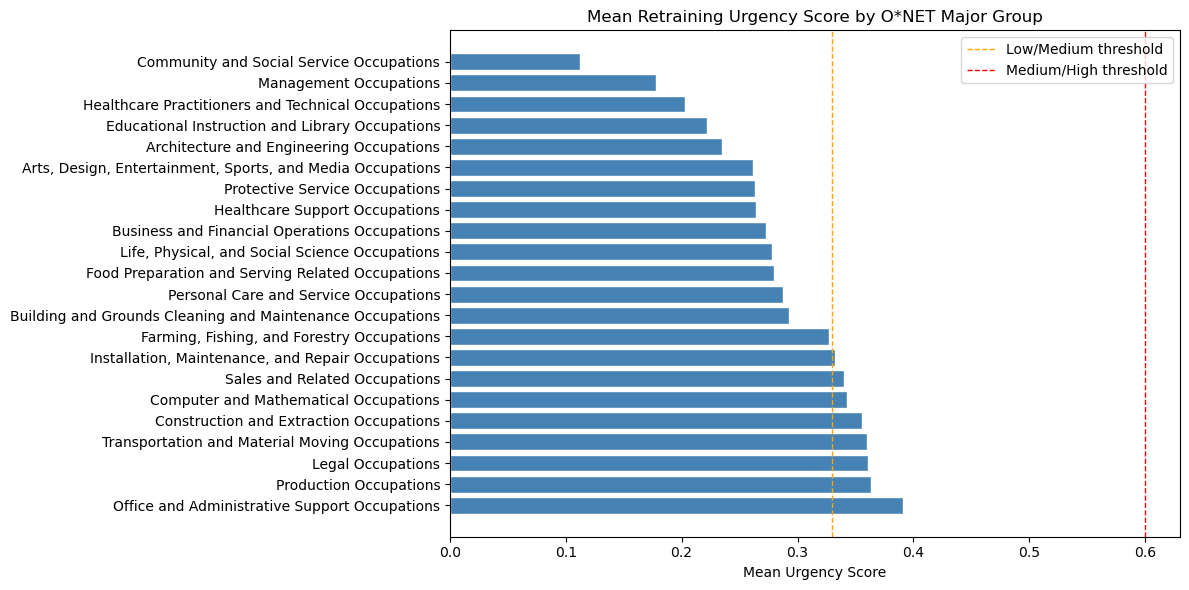

In [33]:
# Distribution of urgency score by major group
group_urgency = (
    clf.groupby('major_group_title')['urgency_score']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(group_urgency['major_group_title'], group_urgency['mean'],
               color='steelblue', edgecolor='white')
ax.axvline(0.33, color='orange', linestyle='--', linewidth=1, label='Low/Medium threshold')
ax.axvline(0.60, color='red',    linestyle='--', linewidth=1, label='Medium/High threshold')
ax.set_title('Mean Retraining Urgency Score by O*NET Major Group')
ax.set_xlabel('Mean Urgency Score')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 7 — Attach task-level detail to each occupation

For the recommendation output we need to surface *which tasks* are most at risk,
not just the occupation. We join `task_penetration` via `onet_task_statements`.

In [26]:
# Inspect onet_tasks to find the linking columns
print('onet_tasks columns:', onet_tasks.columns.tolist())
display(onet_tasks.head(5))

onet_tasks columns: ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source', 'task_clean']


,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,task_clean
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent,direct or coordinate an organization's financi...
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent,appoint department heads or managers and assig...
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent,analyze operations to evaluate performance of ...
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent,"direct, plan, or implement policies, objective..."
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent,"prepare budgets for approval, including those ..."


In [28]:
task_detail = (
    onet_tasks
    .rename(columns={'O*NET-SOC Code': 'occ_code', 'Task': 'task'})
    .merge(task_penetration, on='task', how='left')
)

print('task_detail shape:', task_detail.shape)
display(task_detail.head(5))

task_detail shape: (19533, 10)


,occ_code,Title,Task ID,task,Task Type,Incumbents Responding,Date,Domain Source,task_clean,penetration
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent,direct or coordinate an organization's financi...,0.000
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent,appoint department heads or managers and assig...,0.000
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent,analyze operations to evaluate performance of ...,0.831
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent,"direct, plan, or implement policies, objective...",0.000
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent,"prepare budgets for approval, including those ...",0.000


In [29]:
# For each occupation: top 5 highest-penetration tasks
top_tasks_per_occ = (
    task_detail
    .sort_values('penetration', ascending=False)
    .groupby('occ_code')
    .head(5)
    [['occ_code', 'task', 'penetration']]
    .reset_index(drop=True)
)

print('top_tasks_per_occ shape:', top_tasks_per_occ.shape)
display(top_tasks_per_occ.head(15))

top_tasks_per_occ shape: (4869, 3)


,occ_code,task,penetration
0,41-1012.00,Listen to and resolve customer complaints rega...,1.0
1,17-2061.00,Analyze user needs and recommend appropriate h...,1.0
2,17-3027.01,"Read and interpret blueprints, schematics, wor...",1.0
3,43-4181.00,"Plan routes, itineraries, and accommodation de...",1.0
4,35-9031.00,Answer telephone calls and respond to inquirie...,1.0
5,15-1121.00,Specify inputs accessed by the system and plan...,1.0
6,19-3032.00,Analyze job requirements and content to establ...,1.0
7,13-1111.00,Gather and organize information on problems or...,1.0
8,29-1011.00,Obtain and record patients' medical histories.,1.0
9,43-4181.00,Confer with customers to determine their servi...,1.0


In [34]:
# Cell 1 — join Indonesia gap to occupations
onet_tasks['task_clean'] = onet_tasks['Task'].str.lower().str.strip()
indo_gap['task_clean']   = indo_gap['task'].str.lower().str.strip()

indo_with_occ = indo_gap.merge(
    onet_tasks[['task_clean', 'O*NET-SOC Code', 'Title']].drop_duplicates(),
    on='task_clean', how='left'
)
indo_with_occ['occ_code'] = indo_with_occ['O*NET-SOC Code'].str[:7]
print('Matched:', indo_with_occ['occ_code'].notna().sum(), '/', len(indo_with_occ))

Matched: 288 / 288


In [35]:
# Cell 2 — join to clf to get JobFamily + urgency
indo_full = indo_with_occ.merge(
    clf[['occ_code', 'JobFamily', 'major_group_title',
         'observed_exposure', 'urgency_score', 'retraining_label']],
    on='occ_code', how='left'
)
print('indo_full shape:', indo_full.shape)
display(indo_full.head(3))

indo_full shape: (288, 14)


,geo_id,task,country_pct,penetration,adoption_gap,task_clean,O*NET-SOC Code,Title,occ_code,JobFamily,major_group_title,observed_exposure,urgency_score,retraining_label
0,ID,"identify, investigate, or resolve security bre...",0.118185,0.9764,0.858215,"identify, investigate, or resolve security bre...",11-9199.07,Security Managers,11-9199,Management,Management Occupations,0.0686,0.069577,Low
1,ID,"document software defects, using a bug trackin...",0.126064,0.9753,0.849236,"document software defects, using a bug trackin...",15-1199.01,Software Quality Assurance Engineers and Testers,15-1199,NaN,NaN,NaN,NaN,NaN
2,ID,tutor and assist children individually or in s...,0.141822,0.9798,0.837978,tutor and assist children individually or in s...,25-9041.00,Teacher Assistants,25-9041,NaN,NaN,NaN,NaN,NaN


In [36]:
# Cell 3 — family gap summary
family_gap = (
    indo_full
    .dropna(subset=['JobFamily'])
    .groupby('JobFamily')
    .agg(
        n_tasks          = ('task', 'count'),
        mean_gap         = ('adoption_gap', 'mean'),
        mean_exposure    = ('observed_exposure', 'mean'),
        mean_urgency     = ('urgency_score', 'mean'),
        pct_high_urgency = ('retraining_label', lambda x: (x == 'High').mean())
    )
    .sort_values('mean_gap', ascending=False)
    .reset_index()
)

print('Retraining urgency by Job Family (Indonesia):')
display(family_gap)

Retraining urgency by Job Family (Indonesia):


,JobFamily,n_tasks,mean_gap,mean_exposure,mean_urgency,pct_high_urgency
0,"Installation, Maintenance, and Repair",1,0.814178,0.106700,0.330851,0.0
1,"Life, Physical, and Social Science",6,0.767402,0.313367,0.358545,0.0
2,Community and Social Service,2,0.718460,0.114900,0.088862,0.0
3,Sales and Related,3,0.710252,0.265500,0.262599,0.0
4,Healthcare Practitioners and Technical,2,0.707728,0.111200,0.145131,0.0
5,"Farming, Fishing, and Forestry",1,0.696768,0.020300,0.081001,0.0
6,Food Preparation and Serving Related,1,0.693599,0.073400,0.324893,0.0
7,Architecture and Engineering,1,0.689978,0.145300,0.262142,0.0
8,Management,5,0.548431,0.085740,0.108784,0.0
9,"Education, Training, and Library",201,0.546139,0.135696,0.217135,0.0


---
## Step 8 — Save all datasets for PyTorch pipeline

In [39]:
import os
os.makedirs('processed', exist_ok=True)

indo_full.to_csv('processed/indonesia_gap_with_families.csv', index=False)
family_gap.to_csv('processed/indonesia_family_urgency.csv', index=False)

print('Saved.')
print('\nSummary of files ready for ML pipeline:')
for f in os.listdir('processed'):
    size = os.path.getsize(f'processed/{f}')
    print(f'  {f} — {size/1024:.1f} KB')

Saved.

Summary of files ready for ML pipeline:
  classification_dataset.csv — 126.4 KB
  indonesia_family_urgency.csv — 1.2 KB
  indonesia_gap_with_families.csv — 111.9 KB
  occupation_features.csv — 160.3 KB
  task_penetration_clean.csv — 1863.1 KB
  top_tasks_per_occupation.csv — 565.4 KB


---
## What to fill in after running

| Placeholder | Where to look | What to put |
|---|---|---|
| `GEO_COL` | Step 3 output | column with country name or ISO code |
| `TASK_COL` | Step 4 output | column linking AEI rows to O*NET task |
| `WEIGHT_COL` | Step 4 output | column with usage count or share |
| `ONET_OCC_COL` | Step 7 output | occ code column in `onet_task_statements.csv` |
| `ONET_TASK_COL` | Step 7 output | task text column in `onet_task_statements.csv` |

Steps 6 and 8 (classification dataset) will run cleanly without any of these —
the geographic gap (Steps 3-5) is the only part that needs the placeholders filled.